## The Greg Method

In [ ]:
# Loaded variable 'df' from URI: /home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/data/claims_train.csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv(r'/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/data/claims_train.csv')
df.loc[df["Exposure"]>1, "Exposure"] = 1
df = df.loc[df["VehAge"] < 30, :]
df["AgeCategory"] = "Normal"
df.loc[df["DrivAge"] < 25, "AgeCategory"] = "Young"
df.loc[df["DrivAge"] > 70, "AgeCategory"] = "Old"

# Create column ExposureDays as (Exposure * 365) % 366
df['ExposureDays'] = (df['Exposure'] * 365).round() % 366

# Create TimeBetweenClaims column as ExposureDays/ClaimNb
df['TimeBetweenClaims'] = df['ExposureDays'] / (df['ClaimNb']+1)

df["Risk"] = 1-((df["TimeBetweenClaims"]-df["ExposureDays"])/df["ExposureDays"])-1
df['Risk'] /= df["Exposure"]

df.sort_values("Risk")

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ExposureDays,TimeBetweenClaims,Risk
356819,2260634.0,0,0.500000,E,5,3,56,50,B2,Regular,3608,R23,182.0,182.000000,0.0
356811,2134417.0,0,0.080000,C,10,14,35,95,B10,Diesel,136,R53,29.0,29.000000,0.0
356812,1064854.0,0,0.330000,D,9,12,52,76,B1,Regular,1381,R82,120.0,120.000000,0.0
356813,6054645.0,0,0.370000,D,7,2,61,50,B12,Diesel,695,R72,135.0,135.000000,0.0
356814,1041618.0,0,0.330000,C,12,0,32,50,B11,Regular,251,R25,120.0,120.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70911,7483.0,1,0.002732,B,5,6,28,106,B13,Diesel,51,R24,1.0,0.500000,183.0
250438,9743.0,1,0.002732,D,7,5,42,50,B12,Regular,923,R11,1.0,0.500000,183.0
31389,6138.0,1,0.002732,E,6,0,46,50,B12,Regular,4985,R11,1.0,0.500000,183.0
139795,6384.0,1,0.002732,F,9,0,40,50,B12,Regular,13520,R11,1.0,0.500000,183.0


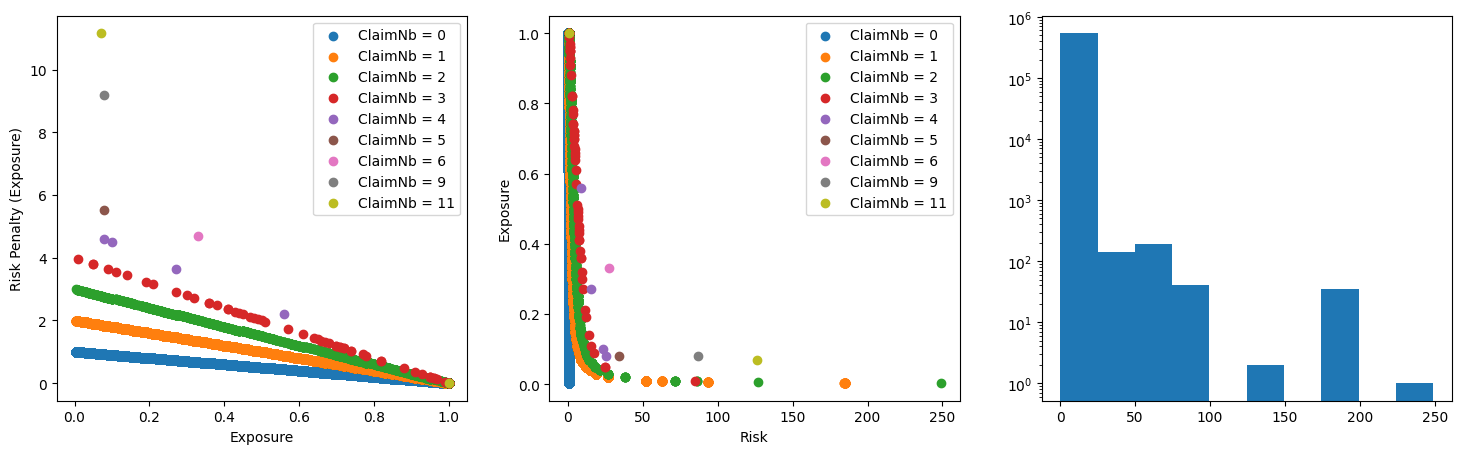

In [6]:
plt.figure(figsize=(18,5))

for i, claimNb in enumerate(sorted(df["ClaimNb"].unique())):
    plt.subplot(1,3,1)
    plt.scatter(df.loc[df["ClaimNb"] == claimNb, ["Exposure"]], ((claimNb+1)*(df["Exposure"].max()-df.loc[df["ClaimNb"] == claimNb, ["Exposure"]])), label = f"ClaimNb = {claimNb}")
    plt.xlabel("Exposure")
    plt.ylabel("Risk Penalty (Exposure)")
    # Adjust Risk Based on Exposure penalty
    df.loc[df["ClaimNb"] == claimNb, "Risk"] += ((claimNb**2+1)*(df["Exposure"].max()-df.loc[df["ClaimNb"] == claimNb, "Exposure"]))
    plt.legend()
    plt.subplot(1,3,2)
    plt.scatter(df.loc[df["ClaimNb"] == claimNb, ["Risk"]], df.loc[df["ClaimNb"] == claimNb, ["Exposure"]], label = f"ClaimNb = {claimNb}")
    plt.xlabel("Risk")
    plt.ylabel("Exposure")
    plt.legend()
plt.subplot(1,3,3)
plt.hist(df["Risk"])
plt.yscale("log")

In [7]:
df["Risk"] /= df["Risk"].max()


df.sort_values("Risk", inplace=True)
df

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,ExposureDays,TimeBetweenClaims,Risk
213378,3061510.0,0,1.000000,D,5,4,38,50,B6,Regular,1662,R11,365.0,365.000000,0.000000
345945,2109104.0,0,1.000000,D,5,18,48,50,B1,Diesel,722,R11,365.0,365.000000,0.000000
345951,1156062.0,0,1.000000,A,6,9,41,50,B6,Regular,9,R24,365.0,365.000000,0.000000
505519,4128468.0,0,1.000000,E,4,3,58,50,B6,Regular,2252,R82,365.0,365.000000,0.000000
85630,2058310.0,0,1.000000,B,5,16,48,50,B4,Regular,84,R24,365.0,365.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537888,7049.0,1,0.002732,E,7,0,35,50,B12,Diesel,6617,R11,1.0,0.500000,0.742991
19404,7039.0,1,0.002732,D,4,0,60,50,B12,Regular,1408,R52,1.0,0.500000,0.742991
19437,7235.0,1,0.002732,E,5,0,61,50,B12,Regular,7752,R11,1.0,0.500000,0.742991
31389,6138.0,1,0.002732,E,6,0,46,50,B12,Regular,4985,R11,1.0,0.500000,0.742991


Text(0, 0.5, 'Cummulative Explained Variance')

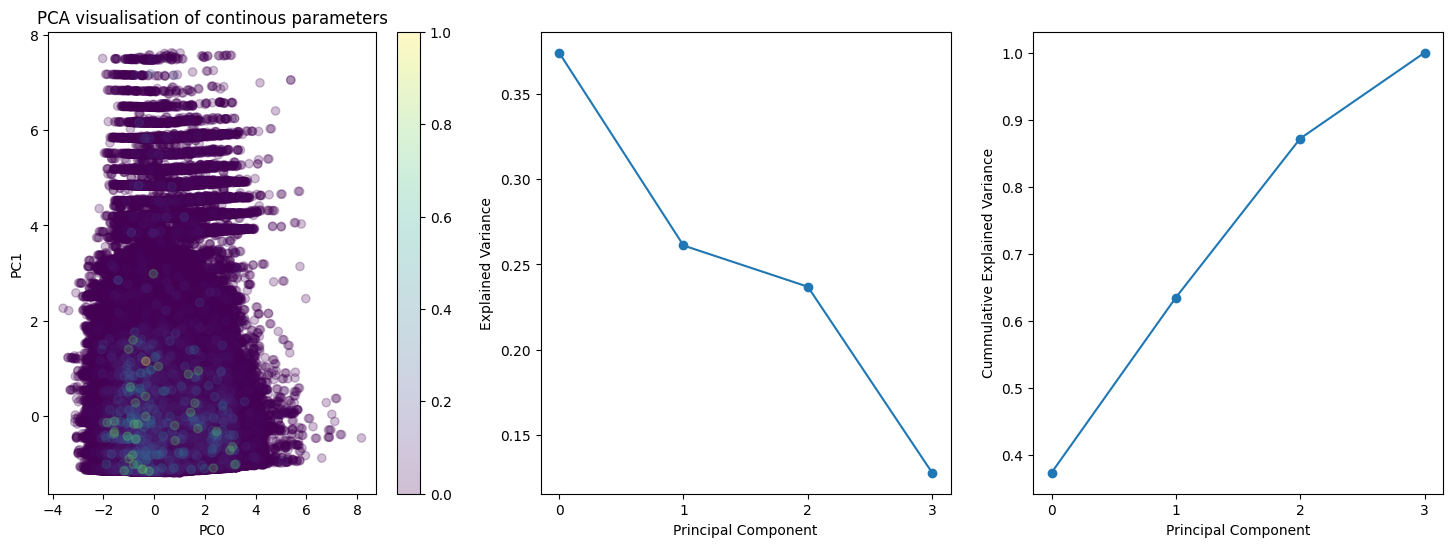

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.figure(figsize=(18, 6))
ContinousData = pd.DataFrame(StandardScaler().fit_transform(df[["VehPower", "DrivAge", "BonusMalus", "Density"]]), columns=["VehPower", "DrivAge", "BonusMalus", "Density"])
pca = PCA().fit(ContinousData)
pcad = pca.transform(ContinousData)

plt.subplot(1, 3, 1)
plt.scatter(pcad[:, 0], pcad[:, 1], c = df["Risk"], alpha=0.25)
plt.title("PCA visualisation of continous parameters")
plt.xlabel("PC0")
plt.ylabel("PC1")
plt.colorbar()


plt.subplot(1, 3, 2)
plt.plot(pca.explained_variance_ratio_, marker = "o")

plt.xticks(range(4))
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance")
plt.subplot(1, 3, 3)
plt.plot([sum(pca.explained_variance_ratio_[:i+1]) for i, ratio in enumerate(pca.explained_variance_ratio_)], marker = "o")
plt.xticks(range(4))
plt.xlabel("Principal Component")
plt.ylabel("Cummulative Explained Variance")


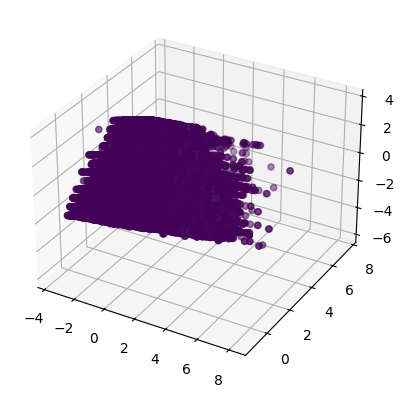

In [5]:

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection="3d")

# Plot the points for the current species
ax.scatter3D(pcad[:, 0], pcad[:, 1], pcad[:, 2], 
            c=df["Risk"])

plt.show()


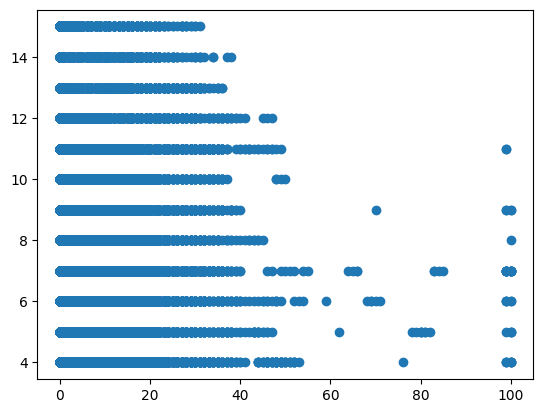

In [6]:
plt.scatter(df["VehAge"], df["VehPower"])